h = 0.01
average y = 1.91082742514542
y near 15 = 0.23143958278769802
average error = 0.3685927534318688
local error near 15 = 0.04093536420886787
lambda(x) = -2 cos(x)
max |1 - 2h cos(x)| = 1.0199999868077532
stability = unstable

h = 0.05
average y = 1.0186021454566716
y near 15 = 0.11986884462031855
average error = 1.2596139807940634
local error near 15 = 0.15250610237639356
lambda(x) = -2 cos(x)
max |1 - 2h cos(x)| = 1.099996829334934
stability = unstable

h = 0.1
average y = 0.5380678135269737
y near 15 = 0.05131833580208075
average error = 1.7381438051572902
local error near 15 = 0.22105661119458356
lambda(x) = -2 cos(x)
max |1 - 2h cos(x)| = 1.1999936586698678
stability = unstable

h = 0.15000000000000002
average y = 0.3205052598252231
y near 15 = 0.020921338696345992
average error = 1.955839479439368
local error near 15 = 0.25145360830034413
lambda(x) = -2 cos(x)
max |1 - 2h cos(x)| = 1.2999893975414025
stability = unstable

h = 0.2
average y = 0.2045681477683726
y near 15 = 0.

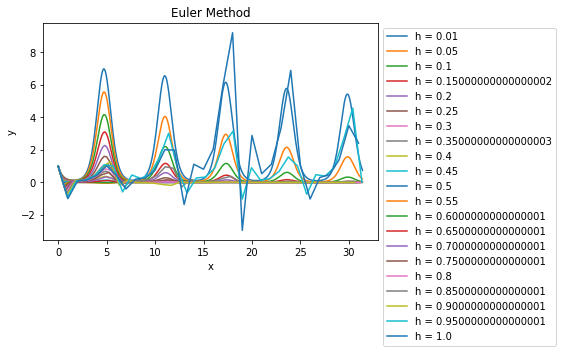

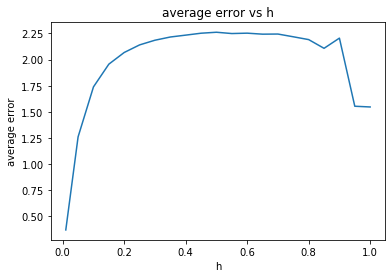

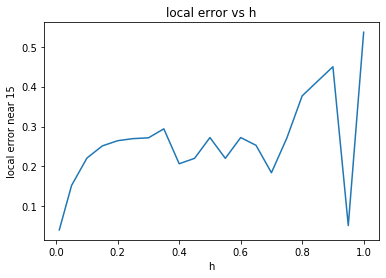

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y * np.cos(x)

def exact(x):
    return np.exp(-2 * np.sin(x))

h_values = [0.01] + list(np.arange(0.05, 1.01, 0.05))

start = 0
end = 10 * np.pi

avg_errors = []
local_errors = []

plt.figure()

for h in h_values:
    n = int((end - start) / h)

    x = [0] * (n + 1)
    y = [0] * (n + 1)

    x[0] = start
    y[0] = 1

    for i in range(n):
        x[i + 1] = x[i] + h
        y[i + 1] = y[i] + h * f(x[i], y[i])

    x = np.array(x)
    y = np.array(y)

    real_y = exact(x)
    error = abs(y - real_y)

    avg_y = np.mean(y)
    avg_error = np.mean(error)

    close_index = 0
    close_dist = abs(x[0] - 15)

    for i in range(len(x)):
        if abs(x[i] - 15) < close_dist:
            close_dist = abs(x[i] - 15)
            close_index = i

    y_near_15 = y[close_index]
    real_y_near_15 = exact(x[close_index])
    local_error = abs(y_near_15 - real_y_near_15)

    avg_errors.append(avg_error)
    local_errors.append(local_error)

    test_values = abs(1 - 2 * h * np.cos(x))
    biggest_test = max(test_values)

    if biggest_test < 1:
        state = "stable"
    else:
        state = "unstable"

    print("h =", h)
    print("average y =", avg_y)
    print("y near 15 =", y_near_15)
    print("average error =", avg_error)
    print("local error near 15 =", local_error)
    print("lambda(x) = -2 cos(x)")
    print("max |1 - 2h cos(x)| =", biggest_test)
    print("stability =", state)
    print()

    plt.plot(x, y, label="h = " + str(h))

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler Method")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

plt.figure()
plt.plot(h_values, avg_errors)
plt.xlabel("h")
plt.ylabel("average error")
plt.title("average error vs h")
plt.show()

plt.figure()
plt.plot(h_values, local_errors)
plt.xlabel("h")
plt.ylabel("local error near 15")
plt.title("local error vs h")
plt.show()